# Toy example with Geometric Brownian Motion Paths as data

## Paramters of the model (regression coefficient and scaling coefficient for feature normalisation may be added)

In [504]:
T = 1  # final time
N = 100  # number of time steps
M = 10  # number of paths to generate
mu = 1.0  # drift coefficient
sigma = 0.2  # volatility coefficient
depth = 8  # depth of the signature truncation
S = 0.9 * T  # observation time
S0 = 100 # initial value of the process
lambda_1 = 0.1  # regularization parameter for ridge regression, with paths_1
lambda_2 = 0.1  # regularization parameter for ridge regression, with paths_2
#prediction_type = "whole path"
prediction_type = "future path"

## Geometric Brownian motion as the solution to the SDE 
## $dS_t = \mu S_t dt+\sigma S_t dW_t$, then 
## $S_t = S_0\exp((\mu-\frac{\sigma^2}{2})t+\sigma W_t)$


In [505]:
#generating Geometric Brownian Motion (GBM) paths (augmented paths (t,x))

import numpy as np
import matplotlib.pyplot as plt

def generate_gbm_path(S0=100, mu=0.1, sigma=0.2, T=1, N=100):
    dt = T / N
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(size=N)
    W = np.cumsum(W) * np.sqrt(dt)  # standard Brownian motion
    S = (mu - 0.5 * sigma**2) * t + sigma * W
    X = S0 * np.exp(S)
    X[0] = S0
    return X

def generate_gbm_data(S0=100, mu=0.1, sigma=0.2, T=1, N=100, M=5):
    t = np.linspace(0, T, N)
    X_samples = np.zeros((M+1, N))
    X_samples[0, :] =  t # set initial stock price for all paths
    #generate and plot M paths
    for i in range(1,M+1):    
        X = generate_gbm_path(S0, mu, sigma, T, N)
        X_samples[i, :] = X
    return X_samples


In [506]:
samples_of_X = generate_gbm_data(S0=S0, T=T, N=N, M=M, mu=mu, sigma=sigma)
t = samples_of_X[0, :]  # time vector for plotting
#For later use in testing we compute another set of paths with different parameters
X_test = generate_gbm_data(S0=S0, T=T, N=N, M=1, mu=mu, sigma=sigma)

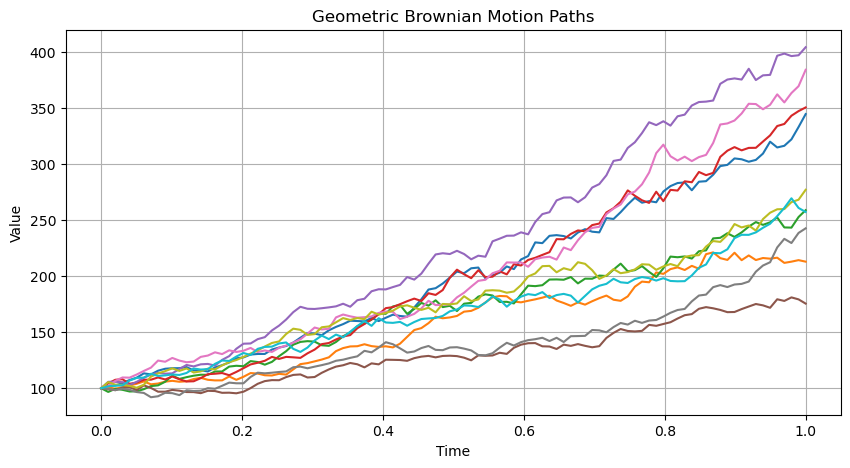

In [507]:
plt.figure(figsize=(10, 5))
for i in range(1,M+1):
    plt.plot(t, samples_of_X[i, :], label=f"Path {i+1}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Geometric Brownian Motion Paths")
#plt.legend()
plt.grid()
plt.show()

## Introduction of a observation horizon $S < T = 1$. Then split sample path $X$ in $X^S$ (regressor) and the whole path $X$ (regressand). The later is calles $Y=X$ in the literature so we rename $Y=X$ and $X=X^S$

In [508]:
def stopping(path: np.ndarray, time: np.ndarray, S: float) -> np.ndarray:
    path_truncated = path[time < S]  # defines a mask, i.e. a boolean array which can be used for subsampling an array
    stopped_value = path_truncated[-1]
    n_pad = len(path) - len(path_truncated)
    path_stopped = np.concatenate([path_truncated, np.full(n_pad, stopped_value)])
    return path_stopped

def get_stopped_data(data, time, S):
    samples_of_X_stopped = np.zeros_like(data)
    for i in range(1, data.shape[0]):
        samples_of_X_stopped[i, :] = stopping(data[i, :], time, S)
    samples_of_X_stopped[0, :] = data[0, :]
    return samples_of_X_stopped

samples_of_X_stopped = get_stopped_data(samples_of_X, samples_of_X[0, :], S)
#rename the latter for clarity in the context of regression (X,Y)
#recall X is stopped and Y is the original/full path, 
Y = samples_of_X
X = samples_of_X_stopped


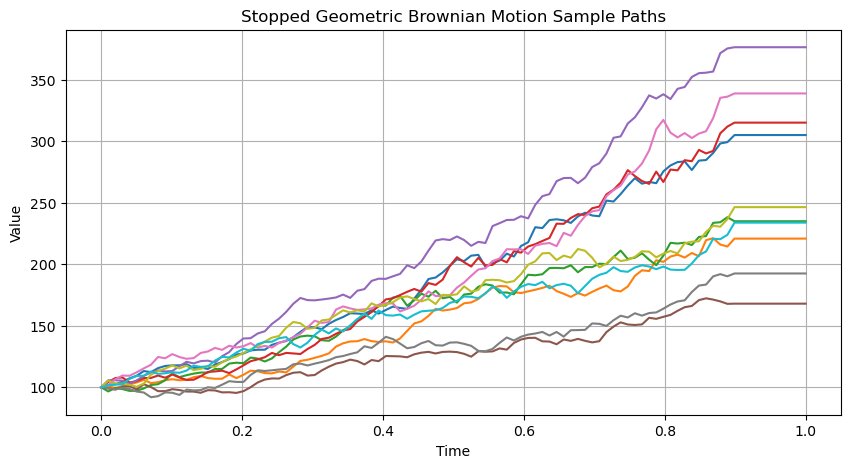

In [509]:
plt.figure(figsize=(10, 5))
for i in range(1, M+1):
    plt.plot(t, X[i, :], label=f"Stopped Path {i}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Stopped Geometric Brownian Motion Sample Paths")
plt.grid()
#plt.legend()
plt.show()

In [510]:
#define the test function f = pi_I where I is a subsample of points in [S,T] (points for which seek to predict the path)
#k = 10 # number of points in the subsample i.e. |I| = k 
#finally get the data of the form (x,y) and (y,f(y))=(y,(y_i_1,...y_i_k))
def get_sampled_paths(Y: np.ndarray, S: float) -> np.ndarray:
    t = Y[0, :]
    s = t[t < S]
    k = N - len(s)
    indices = np.sort(np.random.choice(np.arange(len(s), N), size=k, replace=False))#randomly select k indices between first time point after S and end point t = T (index N)
    return Y[:, indices]  # select values of the paths at the chosen indices (time points), has shape (M+1, k) (M paths and f_Y[0, :] are the sampled time points)

## For later, notice that in Algo I these values f(Y) are not to be scaled (not in a bounded signature)

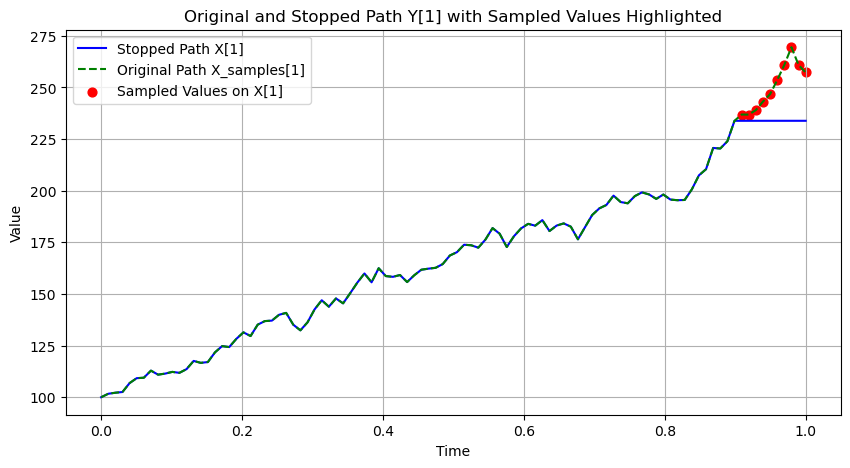

In [511]:
t = Y[0, :]
k = N - len(t[t < S])
indices = np.sort(np.random.choice(np.arange(len(t[t < S]), N), size=k, replace=False))
f_Y = get_sampled_paths(Y, S)  

j = M  # index of the path to plot
plt.figure(figsize=(10, 5))
plt.plot(t, X[j, :], label="Stopped Path X[1]", color="blue")
plt.plot(t, Y[j, :], label="Original Path X_samples[1]", color="green", linestyle="--")
# Highlight the values of X[1] at the sampled indices
#plt.scatter(t[indices], samples_of_X[j, indices], color="red", s=80, marker="o", label="Sampled Values on X[1]")
plt.scatter(t[indices], f_Y[j,:], color="red", s=40, marker="o", label="Sampled Values on X[1]")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Original and Stopped Path Y[1] with Sampled Values Highlighted")
plt.legend()
plt.grid()
plt.show()

# Introducing feature normalisation
## step 1: Defining $\psi$ (Oberhauser/Chevyrev, example 4)

In [512]:
# Implementing the feature normalization of Oberhauser and Chevyrev

def psi(x: float, a: float = 0.5, C: float = 2)->float:
    """
    Parameter range is a > 0 and C >= 1
    """
    y = x**2
    if y <= C:
        return y
    else: return C + (C**(1+a))*(C**(-a)+y**(-a))/a

## For $\mathbb{R}$-valued paths (our case: $k=1$) the tensor norm reduces to the euclidian norm

In [513]:
def norm_of_truncated_tensor_1d(t: np.ndarray) -> float:
    return np.sqrt(np.sum(t**2))

## step 2: Solving the polynomial in $\lambda$: $||\delta_{\lambda}sig(x)||^2=\psi(||sig(x)||)$, where $\delta_{\lambda}sig(x)=(\lambda^0\cdot sig^0(x),\lambda^1\cdot sig^1(x),\lambda^2\cdot sig^2(x),\dots)$

### Notice that for $\mathbb{R}$-valued paths $||\delta_{\lambda}sig(x)||=\sum_{i=0}^m |\int (dx)^i|^2$ where $\int (dx)^i = \int dx\cdots dx$ i times, hence we want to find the roots of (for truncation at level m)
### $Pol(\lambda)=(\sum_{i=0}^m |\lambda^{i}\cdot sig^i(x)|^2)-\psi(\sum_{i=0}^m |sig^i(x)|^2)$

In [514]:
from scipy.optimize import brentq

def root_finding_brent(signature_array: np.ndarray, target: float, tol: float = 1e-6, max_iter: int = 1000) -> float:
    """
    Solve pol(λ) = norm(mult(signature, λ)) - target = 0 for λ ≥ 0
    where mult(signature, λ) gives y[i] = λ^i * signature[i]
    """
    def polynomial(λ):
        if λ == 0:
            powers = np.zeros(len(signature_array))
        else:
            powers = λ ** np.arange(len(signature_array))
        weighted_signature = signature_array * powers  # sig_i * λ^i
        result = norm_of_truncated_tensor_1d(weighted_signature) - target  # Euclidean norm
        if np.isinf(result):
            return 1e15  # Return a large finite number instead of inf
        return result

    # Use Brent's method to find the root
    # Make sure that Pol(a) and Pol(b) have opposite signs (Pol(0)<= -1 garanteed so we need to check that Pol(b)>=0)
    a, b = 0.0, 1e6
    f_a = polynomial(a)
    f_b = polynomial(b)
    
    # Ensure opposite signs
    if f_a * f_b > 0:
        # Same signs - need to find better bounds
        # Since polynomial is monotonic increasing for λ ≥ 0,
        # and f_a < 0, we need to find where it becomes positive
        b = 1e6
        while polynomial(b) < 0 and b < 1e8:
            b *= 10
        if polynomial(b) < 0:
            raise ValueError("Could not find suitable upper bound")

    root = brentq(polynomial, a=0, b=1e6, xtol=tol, maxiter=max_iter)
    return root

## the bisection part of brent algorithm requires f(a) to have opposite sign than f(b).
## here we use the fact that psi(x):[1,infty)->[1,infty) and norm(0)=0 hence polynomial(0) = norm(0)-psi(...)<= -1)
## furthermore considering the explicit expression for the polynomial above, Pol(λ) is positive and monotoneous in λ, hence we expect pol(λ=1e6) a lot bigger than psi(||sig(x)||) which doesn't depend on λ.
## According to the latter argument there exists λ big enough such that pol(λ) > 0, but taking λ=1e6 is a works in practice but could fail in theory (if psi(||sig(x)||) is huge
## The above raises the value of λ and hopes to achive pol(λ)>0 at some point, otherwise raises an error.

In [515]:
def root_finding_bisection(signature_array, target, tol=1e-6, max_iter=60):
    """
    Solve pol(λ) = norm(mult(signature, λ)) - target = 0 for λ ≥ 0
    where mult(signature, λ) gives y[i] = λ^i * signature[i]
    by bisection (monotone in λ).
    """
    
    signature_array = np.asarray(signature_array).flatten()
    
    def lhs(lambda_val):
        """Calculate norm(mult(signature, λ))"""
        powers = lambda_val ** np.arange(len(signature_array))
        mult_result = signature_array * powers
        return np.sqrt(np.sum(mult_result**2))
    
    # Calculate original norm
    orig = lhs(1.0)
    
    if abs(orig - target) < tol:
        return 1.0
    
    # Adaptive bound finding
    if orig > target:
        lo, hi = 0.0, 1.0
    else:
        lo = 1.0
        hi = 2.0
        # Find upper bound adaptively
        while lhs(hi) < target and hi < 1000:
            hi *= 2
        if hi >= 1000:
            raise ValueError("Could not find suitable upper bound for λ")
    
    # Bisection search
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        val = lhs(mid)
        
        if abs(val - target) < tol:
            return mid
            
        if val > target:
            hi = mid
        else:
            lo = mid
            
    return mid

### Notice the above has to be done for every path $X[j],j\geq 1$ separatly giving a different $\lambda$ for every such path. Now we scale the paths which implements the bounded signature due to $\delta_{\lambda}(sig(x))=sig(\lambda\cdot x)$

In [516]:
def compute_lambdas(sig_X):   
    lambdas = [] 
    for i in range(0, sig_X.shape[0]):
        norm_sig_X = norm_of_truncated_tensor_1d(sig_X[i, :])
        lambdas.append(root_finding_brent(sig_X[i, :], psi(norm_sig_X)))
    return np.array(lambdas).reshape(-1, 1)

In [517]:
## Defining the function to compute the augmented signatures already needed for the computation of lambdas
import jax
import signax

#takes as input (unaugmented path) with path[0] = t and paths path[j] for j between 1 and M+1, where M is the number of paths)
def compute_augmented_signatures(paths, depth):
    signatures = []
    for j in range(1, paths.shape[0]): #don't want to stack time with time so starting at j = 1 rather than j = 0
        paths_augmented = jax.numpy.stack([paths[0, :], paths[j, :]], axis=1)#need stack along axis 1 because in signax documentation input path has shape (length, dim). 
        sig = signax.signature(paths_augmented, depth=depth)
        signatures.append(sig)
    signatures = jax.numpy.stack(signatures)
    return signatures

In [518]:
# rescaling of the paths equivalent to rescaling signature in order to implement the bounded signature
def lambda_rescaling(paths: np.ndarray) -> np.ndarray:
    signature = compute_augmented_signatures(paths, depth)
    lambdas = compute_lambdas(signature)
    return paths[1:, :] * lambdas, lambdas

In [519]:
# normalizing the paths in order for better learning performance, emperically
def statistical_normalization(paths: np.ndarray) -> tuple:
    # emperical moments of the generated data
    Mean = np.mean(paths[1:, :], axis=1)  # mean of the stopped paths
    Std = np.std(paths[1:, :], axis=1)  # standard
    return (paths[1:, :] - Mean.reshape(-1, 1)) / Std.reshape(-1, 1), Mean, Std

In [520]:
X_original = X.copy()  # keep the original X for later use
Y_original = Y.copy()  # keep the original Y for later use
X_test_original = X_test.copy()

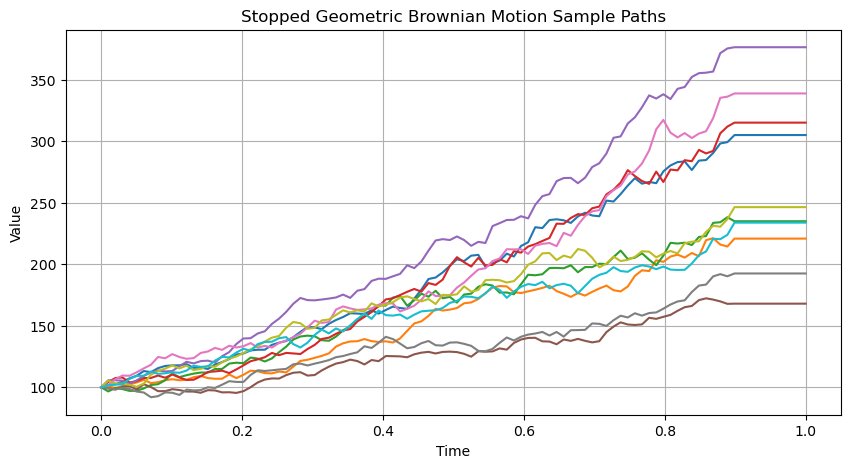

In [521]:
plt.figure(figsize=(10, 5))
for i in range(1, M+1):
    plt.plot(t, X[i, :], label=f"Stopped Path {i}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Stopped Geometric Brownian Motion Sample Paths")
plt.grid()
#plt.legend()
plt.show()

In [522]:
# normalize the data for better learning performance
X[1:, :], mean_X, std_X = statistical_normalization(X) 
Y[1:, :], mean_Y, std_Y = statistical_normalization(Y) 
X_test[1:, :], mean_X_test, std_X_test = statistical_normalization(X_test)

# Remember to add the mean back to prediction

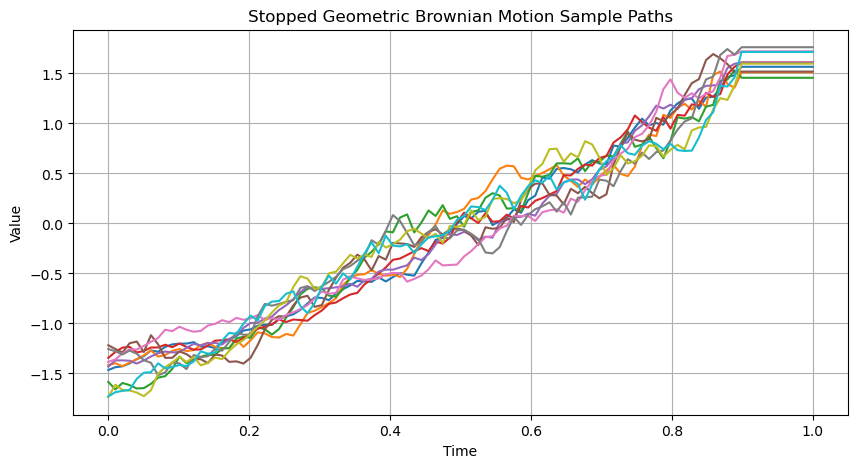

In [523]:
plt.figure(figsize=(10, 5))
for i in range(1, M+1):
    plt.plot(t, X[i, :], label=f"Stopped Path {i}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Stopped Geometric Brownian Motion Sample Paths")
plt.grid()
#plt.legend()
plt.show()

In [524]:
# VERIFICATION: Check that stopped paths remain constant after per-path normalization
print("=== VERIFICATION: STOPPED PATH BEHAVIOR AFTER PER-PATH NORMALIZATION ===")

stop_index = np.where(t >= S)[0][0]
print(f"Stopping time S: {S}")
print(f"Stop index: {stop_index}")

print(f"\nORIGINAL stopped paths (X_original) - should be constant after S:")
for i in range(1, min(4, X_original.shape[0])):
    values_after_S = X_original[i, stop_index:]
    is_constant = np.all(np.isclose(values_after_S, values_after_S[0], rtol=1e-10))
    print(f"  Path {i}: constant after S? {is_constant}, values: {values_after_S[:3]}...")

print(f"\nNORMALIZED stopped paths (X) - should STILL be constant after S:")
for i in range(1, min(4, X.shape[0])):
    values_after_S = X[i, stop_index:]
    is_constant = np.all(np.isclose(values_after_S, values_after_S[0], rtol=1e-10))
    std_after_S = np.std(values_after_S)
    print(f"  Path {i}: constant after S? {is_constant}, std: {std_after_S:.10f}, values: {values_after_S[:3]}...")

print(f"\n>>> RESULT: With per-path normalization, stopped structure is preserved!")

=== VERIFICATION: STOPPED PATH BEHAVIOR AFTER PER-PATH NORMALIZATION ===
Stopping time S: 0.9
Stop index: 90

ORIGINAL stopped paths (X_original) - should be constant after S:
  Path 1: constant after S? True, values: [305.0530401 305.0530401 305.0530401]...
  Path 2: constant after S? True, values: [220.88362495 220.88362495 220.88362495]...
  Path 3: constant after S? True, values: [235.0021998 235.0021998 235.0021998]...

NORMALIZED stopped paths (X) - should STILL be constant after S:
  Path 1: constant after S? True, std: 0.0000000000, values: [1.56701867 1.56701867 1.56701867]...
  Path 2: constant after S? True, std: 0.0000000000, values: [1.51271646 1.51271646 1.51271646]...
  Path 3: constant after S? True, std: 0.0000000000, values: [1.45686582 1.45686582 1.45686582]...

>>> RESULT: With per-path normalization, stopped structure is preserved!


In [525]:
X[1:, :], lambdas_X = lambda_rescaling(X)
Y[1:, :], lambdas_Y = lambda_rescaling(Y)
X_test[1:, :], lambdas_X_test = lambda_rescaling(X_test)

/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_94769/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))


# Construction of matrices for normal equations
## Construction of data vector $B_{ij}=f_j(y_i)=(y_i)_{t_j}$

In [526]:
# recall that the first row in f_Y has the time values, which we want to remove to get the matrix B
def get_B(paths_2, S):
    if prediction_type == "future path":
        B = get_sampled_paths(paths_2, S)[1:, :]
    elif prediction_type == "whole path":
        B = paths_2[1:, :]
    return B
# Notice that B is the only object in Algo I that depends on the function f!

## Construction of the signature kernel matrices $A_X$: Signature Kernel with $X$, $A_Y$: Signature Kernel with $Y$

In [527]:
## Computing signature kernel matrices of augmented paths
import jax.numpy as jnp
from powersig.jax.algorithm import PowerSigJax

def powersig_kernel_matrix_augmented(paths, depth):
    augmented_paths = jnp.stack([jnp.stack([paths[0, :], paths[j, :]], axis=1) for j in range(1, paths.shape[0])])
    powersig = PowerSigJax(depth)
    return powersig(augmented_paths)


## Construction of the Signature matrix $C$

In [528]:
## Dimension of the truncated tensor algebra (m_d in Algo I). In our case, the data is 1-dimensional, so we set d = 1.

def dimensionality_regression(depth, dimension_data):
    """
    Function to compute the dimensionality of the regression problem.
    For d > 1, m_d = (d^{m+1} - 1) / (d - 1)
    For d = 1, m_d = M
    """
    if dimension_data > 1:
        return (dimension_data ** (depth + 1) - 1) / (dimension_data - 1)
    else:
        return depth  # M for d = 1
        

## Solving the normal equations

In [529]:
from sklearn.linear_model import ridge_regression

def regression_coeffs(paths_1, paths_2, lambda_1 = 1.0, lambda_2 = 1.0):
    # Compute the matrices for regression
    m_d = dimensionality_regression(depth, 1)
    C = compute_augmented_signatures(paths_2,m_d)
    B = get_B(paths_2, S)
    # Compute the kernel matrices for the augmented paths
    kernel_matrix_aug_1 = powersig_kernel_matrix_augmented(paths_1, depth)
    kernel_matrix_aug_2 = powersig_kernel_matrix_augmented(paths_2, depth)
    # Perform ridge regression to find coefficients
    beta = ridge_regression(kernel_matrix_aug_1, C, alpha=lambda_1*M)
    alpha = ridge_regression(kernel_matrix_aug_2, B, alpha=lambda_2*M)
    if B.shape[1] == 1:#if we perform single value prediction reshape alpha to ensure it has shape (M, 1) and not (M,)
        alpha = alpha.reshape(-1, 1)
        return alpha, beta, C
    else:
        return alpha, beta, C

# Construction of estimator $\psi_f = \sum_l\sum_k \alpha_{kl} \langle sig_m(Y[l]),\Upsilon\rangle\cdot e_k$

## kernel_vec $_j=\langle sig(X[j, :]),sig(X_{test})\rangle$ 

In [530]:
# Inner product in definition of psi_f

def signature_kernel_vector(paths, path_new, order=8):

    augmented_paths = jnp.stack([jnp.stack([paths[0, :], paths[j, :]], axis=1) for j in range(1, paths.shape[0])])  # (M, N, 2)
    augmented_paths_new = jnp.stack([path_new[0, :], path_new[1, :]], axis=1).reshape(1, path_new.shape[1], 2)  # (1, N, 2)
    powersig = PowerSigJax(order)
    kernel_vector = powersig(augmented_paths, augmented_paths_new)
    return kernel_vector

## Construction of estimator $\Upsilon=\sum_i\sum_j\beta_{ji}\cdot$ (kernel_vec) $_j e_i$

In [531]:
def signature_estimator(paths_1, paths_2, paths_new, lambda_1=1.0, lambda_2=1.0):
    kernel_vec = signature_kernel_vector(paths_1, paths_new, order=8)
    alpha, beta, C = regression_coeffs(paths_1, paths_2, lambda_1=lambda_1, lambda_2=lambda_2)
    sig_est = jnp.dot(beta, kernel_vec)
    return sig_est, alpha, C

In [532]:
def estimator(paths_1, paths_2, paths_new, lambda_1=1.0, lambda_2=1.0):
    sig_est, alpha, C = signature_estimator(paths_1, paths_2, paths_new, lambda_1=lambda_1, lambda_2=lambda_2)
    return (alpha @ C @ sig_est).reshape(1, -1)

In [533]:
## predicted values at t_pred using the estimator on the test path
pred_values = estimator(X, Y, X_test, lambda_1, lambda_2)

# Notice that taking larger values of lambda_1 and lambda_2 leads to more regularized predictions, i.e. smoother paths.

In [534]:
#rescaling prediction to original scale, by inverting statistical normalization and lambda rescaling. Mind the order of operations!
pred_values_rescaled = (pred_values / lambdas_X_test[0]) * std_X_test + mean_X_test

In [535]:

# # Manual post processing of the pointwise prediction for t in [S, T]. This is optional
# if prediction_type == "future path":
#     pred_values_rescaled_shifted = pred_values_rescaled.copy()  
#     pred_values_rescaled_shifted = pred_values_rescaled +  (X_test_original[1, len(t[t<S])] - pred_values_rescaled[0,0]) # adjust the first value to match the original path's starting point



In [536]:
# compute RMSE of the prediction
def compute_rmse(values, path):
    t = path[0, :]  # time vector for the test paths
    if prediction_type == "whole path":
        # Compute RMSE for whole path predictions
        rmse = np.sqrt(np.mean((values - path) ** 2))
    elif prediction_type == "future path":
        # Compute RMSE for future path predictions
        rmse = np.sqrt(np.mean((values[0] - path[:, t >= S]) ** 2))
    return rmse

In [537]:
print(compute_rmse(pred_values_rescaled, X_test_original))

239.80522001986077


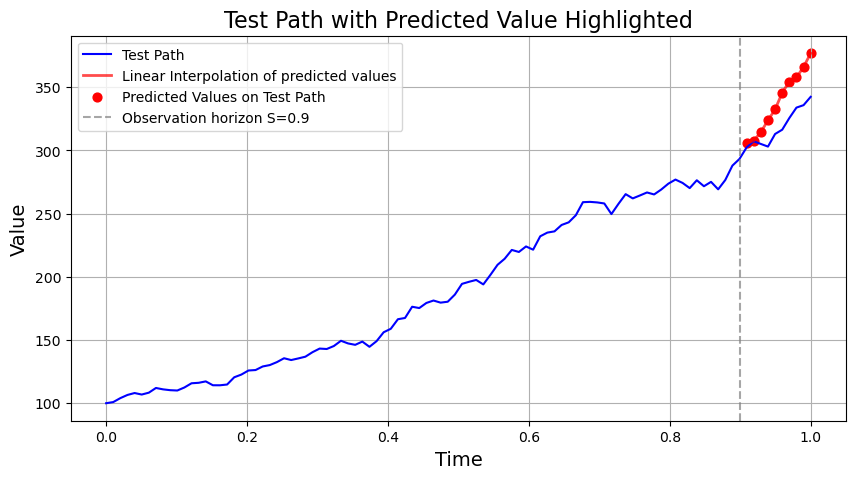

In [538]:
# Plot for 'whole path' prediction type
# Adjusting for initial offset (which doesn't seem to be learned well by the model)
plt.figure(figsize=(10, 5))
plt.plot(t, X_test_original[1, :], label="Test Path", color="blue")
if prediction_type == "whole path":
    t_pred = t
    plt.plot(t_pred, pred_values_rescaled[0, :], color="red", linestyle="-", alpha=0.7, linewidth=2, label="Linear Interpolation of predicted values")
    plt.scatter(t_pred, pred_values_rescaled[0, :], color="red", s=40, marker="o", label="Predicted Values on Test Path")
elif prediction_type == "future path":
    t_pred = t[indices]
    plt.plot(t_pred, pred_values_rescaled[0, :], color="red", linestyle="-", alpha=0.7, linewidth=2, label="Linear Interpolation of predicted values")
    plt.scatter(t_pred, pred_values_rescaled[0, :], color="red", s=40, marker="o", label="Predicted Values on Test Path")
    #plt.plot(t_pred, pred_values_rescaled_shifted[0, :], color="red", linestyle="-", alpha=0.7, linewidth=2, label="Linear Interpolation of predicted values")
    #plt.scatter(t_pred, pred_values_rescaled_shifted[0, :], color="red", s=40, marker="o", label="Predicted Values on Test Path")

plt.axvline(x=S, color='gray', linestyle='--', alpha=0.7, label=f'Observation horizon S={S}')

plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.title("Test Path with Predicted Value Highlighted", fontsize=16)
plt.grid()
plt.legend()
plt.show()

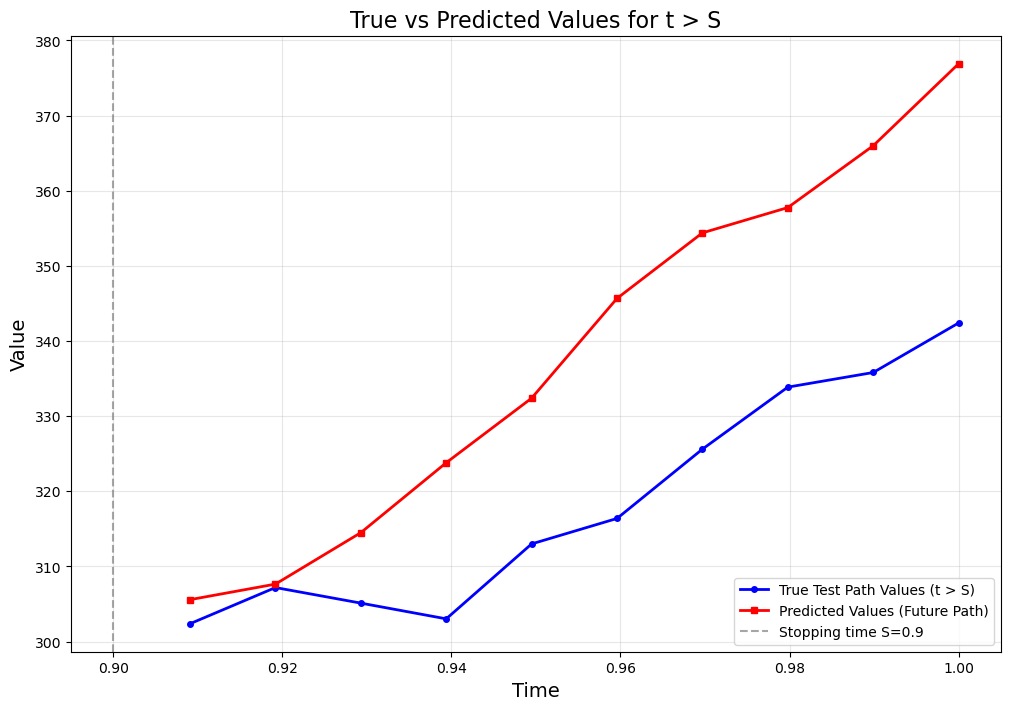

Prediction type: future path
Number of time points with t > S: 10
Number of predicted points: 10
Time range for predictions: 0.909 to 1.000
Time range for t > S: 0.909 to 1.000
True values range: 302.379 to 342.400


In [539]:
# Combined plot for X_test_original and predicted values for t>S
plt.figure(figsize=(12, 8))

# Get time points for prediction region
t_pred_region = t[t > S]

if prediction_type == "future path":
    # For future path prediction, get the indices and corresponding predicted values
    t_pred_indices = t[indices]  # Time points where predictions were made
    pred_values_to_plot = pred_values_rescaled[0, :] if 'pred_values_rescaled_shifted' in locals() else pred_values_rescaled[0, :]
    #pred_values_to_plot = pred_values_rescaled_shifted[0, :] if 'pred_values_rescaled_shifted' in locals() else pred_values_rescaled[0, :]
    
    # Plot true values for t>S
    plt.plot(t_pred_region, X_test_original[1, t > S], 'b-', linewidth=2, marker='o', markersize=4, label='True Test Path Values (t > S)')
    
    # Plot predicted values
    plt.plot(t_pred_indices, pred_values_to_plot, 'r-', linewidth=2, marker='s', markersize=4, label='Predicted Values (Future Path)')
    
elif prediction_type == "whole path":
    # For whole path prediction, use all time points > S
    plt.plot(t_pred_region, X_test_original[1, t > S], 'b-', linewidth=2, marker='o', markersize=4, label='True Test Path Values (t > S)')
    plt.plot(t_pred_region, pred_values_rescaled[0, t > S], 'r-', linewidth=2, marker='s', markersize=4, label='Predicted Values (Whole Path)')

# Add vertical line at stopping time
plt.axvline(x=S, color='gray', linestyle='--', alpha=0.7, label=f'Stopping time S={S}')

plt.xlabel('Time', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.title('True vs Predicted Values for t > S', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print some statistics
print(f"Prediction type: {prediction_type}")
print(f"Number of time points with t > S: {len(t_pred_region)}")
if prediction_type == "future path":
    print(f"Number of predicted points: {len(pred_values_rescaled[0, :])}")
    print(f"Time range for predictions: {t_pred_indices[0]:.3f} to {t_pred_indices[-1]:.3f}")
print(f"Time range for t > S: {t_pred_region[0]:.3f} to {t_pred_region[-1]:.3f}")
print(f"True values range: {X_test_original[1, t > S].min():.3f} to {X_test_original[1, t > S].max():.3f}")

## averaging RMSE over 10 repetitions for every M[i] in M_ for one and the same test path

In [540]:
# import matplotlib.pyplot as plt

# # Get true values at prediction points
# S = 0.95 * T  # observation time
# M_ = [10, 20, 50, 70, 100, 120, 150]
# rmse_ = np.zeros((len(M_), 10))
# N = 200
# X_test_rmse = generate_gbm_data(S0=S0, T=T, N=N, M=1, mu=mu, sigma=sigma)
# X_test_original = X_test_rmse.copy()
# t = X_test[0, :]
# for i in range(0, len(M_)):
#     M_current = M_[i]
#     for j in range(0, 10):  
#         #Generate new training data with M_current paths
#         Y_current = generate_gbm_data(S0=S0, T=T, N=N, M=M_current, mu=mu, sigma=sigma) 
#         time = Y_current[0, :]  # time vector for plotting
#         # Apply stopping
#         X_current =  get_stopped_data(Y_current, time, S)
#         # Normalize the data
#         X_current[1:, :], mean_X, std_X = statistical_normalization(X_current)
#         Y_current[1:, :], mean_Y, std_Y = statistical_normalization(X_current)
#         X_test_rmse[1:, :], mean_X_test, std_X_test = statistical_normalization(X_test_rmse)

#         X_current[1:, :], lambdas_X = lambda_rescaling(X_current)
#         Y_current[1:, :], lambdas_Y = lambda_rescaling(Y_current)
#         X_test_rmse[1:, :], lambdas_X_test = lambda_rescaling(X_test_rmse)
#         # Make prediction and rescale it
#         pred_values = estimator(X_current, Y_current, X_test_rmse, lambda_1, lambda_2)
#         pred_values_rescaled = (pred_values / lambdas_X_test[0]) * std_X_test + mean_X_test

#         # # Manual post processing of the pointwise prediction for t in [S, T]
#         # if prediction_type == "future path":
#         #     pred_values_rescaled_shifted = pred_values_rescaled.copy()  
#         #     pred_values_rescaled_shifted = pred_values_rescaled +  (X_test_original[1, len(time[time<S])] - pred_values_rescaled[0,0]) # adjust the first value to match the original path's starting point
#         rmse_current = np.sqrt(np.mean((pred_values - X_test_original[1, len(time[time<S]):])**2))
#         rmse_[i, j] = rmse_current

In [541]:
import matplotlib.pyplot as plt

# Get true values at prediction points
S = 0.95 * T  # observation time
M_ = [10, 20, 50, 70, 100, 120, 150, 170, 200]

rmse_ = np.zeros((len(M_), 10))
N = 200
X_test_rmse = generate_gbm_data(S0=S0, T=T, N=N, M=1, mu=mu, sigma=sigma)
X_test_original = X_test_rmse.copy()
t = X_test[0, :]

# === NEW: storage for condition numbers ===
kappa_Az = np.zeros((len(M_), 10))
kappa_Ay = np.zeros((len(M_), 10))

# Computation of condition number of the relevant matrices for ridge regression (the one's a)
def cond_ridge(K, alpha):
    K = np.array(K)
    A = K.T @ K + alpha * np.eye(K.shape[0])  # K is MxM here
    s = np.linalg.svd(A, compute_uv=False)
    # guard against zeros (shouldn’t occur with α>0, but just in case)
    return float(s.max() / s.min()) if np.all(s > 0) else np.inf

for i in range(0, len(M_)):
    M_current = M_[i]
    for j in range(0, 10):  
        #Generate new training data with M_current paths
        Y_current = generate_gbm_data(S0=S0, T=T, N=N, M=M_current, mu=mu, sigma=sigma) 
        time = Y_current[0, :]  # time vector for plotting
        # Apply stopping
        X_current =  get_stopped_data(Y_current, time, S)
        # Normalize the data
        X_current[1:, :], mean_X, std_X = statistical_normalization(X_current)
        Y_current[1:, :], mean_Y, std_Y = statistical_normalization(Y_current)
        X_test_rmse[1:, :], mean_X_test, std_X_test = statistical_normalization(X_test_rmse)

        X_current[1:, :], lambdas_X = lambda_rescaling(X_current)
        Y_current[1:, :], lambdas_Y = lambda_rescaling(Y_current)
        X_test_rmse[1:, :], lambdas_X_test = lambda_rescaling(X_test_rmse)

        # === NEW: compute κ2 for both Gram matrices at this (i,j) ===
        Kz = powersig_kernel_matrix_augmented(X_current, depth)  # A_z (X-side)
        Ky = powersig_kernel_matrix_augmented(Y_current, depth)  # A_y (Y-side)
        alpha_z = lambda_1 * M_current
        alpha_y = lambda_2 * M_current
        kappa_Az[i, j] = cond_ridge(Kz, alpha_z)
        kappa_Ay[i, j] = cond_ridge(Ky, alpha_y)

        # Make prediction and rescale it
        pred_values = estimator(X_current, Y_current, X_test_rmse, lambda_1, lambda_2)
        pred_values_rescaled = (pred_values / lambdas_X_test[0]) * std_X_test + mean_X_test

        # # Manual post processing of the pointwise prediction for t in [S, T]
        # if prediction_type == "future path":
        #     pred_values_rescaled_shifted = pred_values_rescaled.copy()  
        #     pred_values_rescaled_shifted = pred_values_rescaled +  (X_test_original[1, len(time[time<S])] - pred_values_rescaled[0,0]) # adjust the first value to match the original path's starting point




        rmse_current = np.sqrt(np.mean((pred_values - X_test_original[1, len(time[time<S]):])**2))
        rmse_[i, j] = rmse_current

/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_94769/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))
/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_94769/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))
/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_94769/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))
/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_94769/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))
/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_94769/3293619238.py:12: RuntimeWarning: overflow encountered in power
  powers = λ ** np.arange(len(signature_array))
/var/folders/4g/6hk507fj4_z52gc5hhkkpdrr0000gn/T/ipykernel_94769/3293619238.py:12: RuntimeWarning: overflow encount

KeyboardInterrupt: 

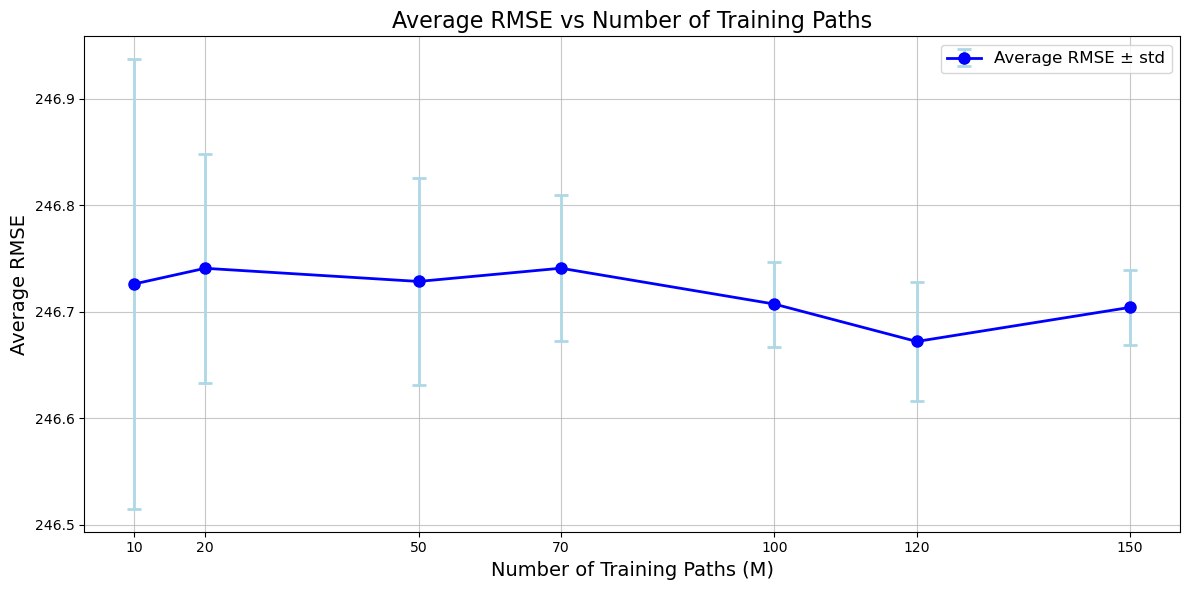

In [ ]:
average_rmse = np.mean(rmse_, axis=1)
std_rmse = np.std(rmse_, axis=1)

plt.figure(figsize=(12, 6))
plt.errorbar(M_, average_rmse, yerr=std_rmse, marker='o', linestyle='-', 
             linewidth=2, markersize=8, capsize=5, capthick=2,
             color='blue', ecolor='lightblue', label='Average RMSE ± std')
plt.xlabel("Number of Training Paths (M)", fontsize=14)
plt.ylabel("Average RMSE", fontsize=14)
plt.title("Average RMSE vs Number of Training Paths", fontsize=16)
plt.xticks(M_)
plt.grid(True, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [547]:
# CONVERGENCE ANALYSIS: Quantify how RMSE converges as M increases
M_ = [10, 20, 50, 70, 100, 120, 150]
# 1. Compute convergence rate using power law fitting
from scipy.optimize import curve_fit
import warnings

def power_law(x, a, b):
    """Power law: y = a * x^b"""
    return a * np.power(x, b)

def exponential_decay(x, a, b, c):
    """Exponential decay: y = a * exp(-b*x) + c"""
    return a * np.exp(-b * x) + c

def fit_convergence_rate(M_vals, rmse_vals, model='power'):
    """Fit convergence model and return parameters"""
    try:
        if model == 'power':
            # Fit power law: RMSE ~ M^(-α)
            popt, pcov = curve_fit(power_law, M_vals, rmse_vals, 
                                 bounds=([-np.inf, -np.inf], [np.inf, 0]))
            return popt, pcov
        elif model == 'exponential':
            # Fit exponential decay
            popt, pcov = curve_fit(exponential_decay, M_vals, rmse_vals,
                                 bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
            return popt, pcov
    except Exception as e:
        print(f"Fitting failed for {model}: {e}")
        return None, None

# Fit power law to the data
print("=== CONVERGENCE ANALYSIS ===")

# Check if RMSE data matches current M_ array
if 'average_rmse' not in locals():
    print("⚠ Error: average_rmse not computed yet! Please run the RMSE computation cell first.")
    power_params, power_cov = None, None
elif len(M_) != len(average_rmse):
    print(f"⚠ Error: Size mismatch between M_ ({len(M_)} elements) and average_rmse ({len(average_rmse)} elements)!")
    print(f"Current M_: {M_}")
    print(f"Available average_rmse length: {len(average_rmse)}")
    print("Please recompute RMSE data for the current M_ array.")
    power_params, power_cov = None, None
else:
    power_params, power_cov = fit_convergence_rate(M_, average_rmse, 'power')

if power_params is not None:
    a_power, b_power = power_params
    power_errors = np.sqrt(np.diag(power_cov))
    
    print(f"Power Law Fit: RMSE ≈ {a_power:.4f} * M^({b_power:.4f})")
    print(f"Convergence rate α = {-b_power:.4f} ± {power_errors[1]:.4f}")
    
    # Theoretical expectation for Monte Carlo: α ≈ 0.5
    print(f"Theoretical Monte Carlo rate: α = 0.5")
    print(f"Your empirical rate: α = {-b_power:.4f}")
    
    if abs(b_power + 0.5) < 0.1:
        print("✓ Close to theoretical Monte Carlo convergence rate!")
    else:
        print("⚠ Deviates from standard Monte Carlo rate")

    # 2. Compute relative improvement
    relative_improvement = (average_rmse[0] - average_rmse[-1]) / average_rmse[0] * 100
    print(f"\nRelative improvement from M={M_[0]} to M={M_[-1]}: {relative_improvement:.2f}%")

    # 3. Compute convergence criterion (when RMSE stops improving significantly)
    rmse_diffs = np.diff(average_rmse)
    percent_improvements = -rmse_diffs / average_rmse[:-1] * 100
else:
    print("⚠ Skipping convergence analysis - please compute RMSE first.")
    relative_improvement = None
    percent_improvements = None

if percent_improvements is not None:
    print(f"\nPercent improvements between consecutive M values:")
    for i, (m1, m2, improvement) in enumerate(zip(M_[:-1], M_[1:], percent_improvements)):
        print(f"  M={m1} to M={m2}: {improvement:.2f}% improvement")

    # Find when improvement becomes < 5%
    significant_threshold = 5.0
    converged_idx = np.where(percent_improvements < significant_threshold)[0]
    if len(converged_idx) > 0:
        convergence_point = M_[converged_idx[0]]
        print(f"\n✓ Convergence achieved around M={convergence_point} (improvement < {significant_threshold}%)")
    else:
        print(f"\n⚠ No convergence detected with {significant_threshold}% threshold")

=== CONVERGENCE ANALYSIS ===
Power Law Fit: RMSE ≈ 246.7763 * M^(-0.0001)
Convergence rate α = 0.0001 ± 0.0000
Theoretical Monte Carlo rate: α = 0.5
Your empirical rate: α = 0.0001
⚠ Deviates from standard Monte Carlo rate

Relative improvement from M=10 to M=150: 0.01%

Percent improvements between consecutive M values:
  M=10 to M=20: -0.01% improvement
  M=20 to M=50: 0.01% improvement
  M=50 to M=70: -0.01% improvement
  M=70 to M=100: 0.01% improvement
  M=100 to M=120: 0.01% improvement
  M=120 to M=150: -0.01% improvement

✓ Convergence achieved around M=10 (improvement < 5.0%)


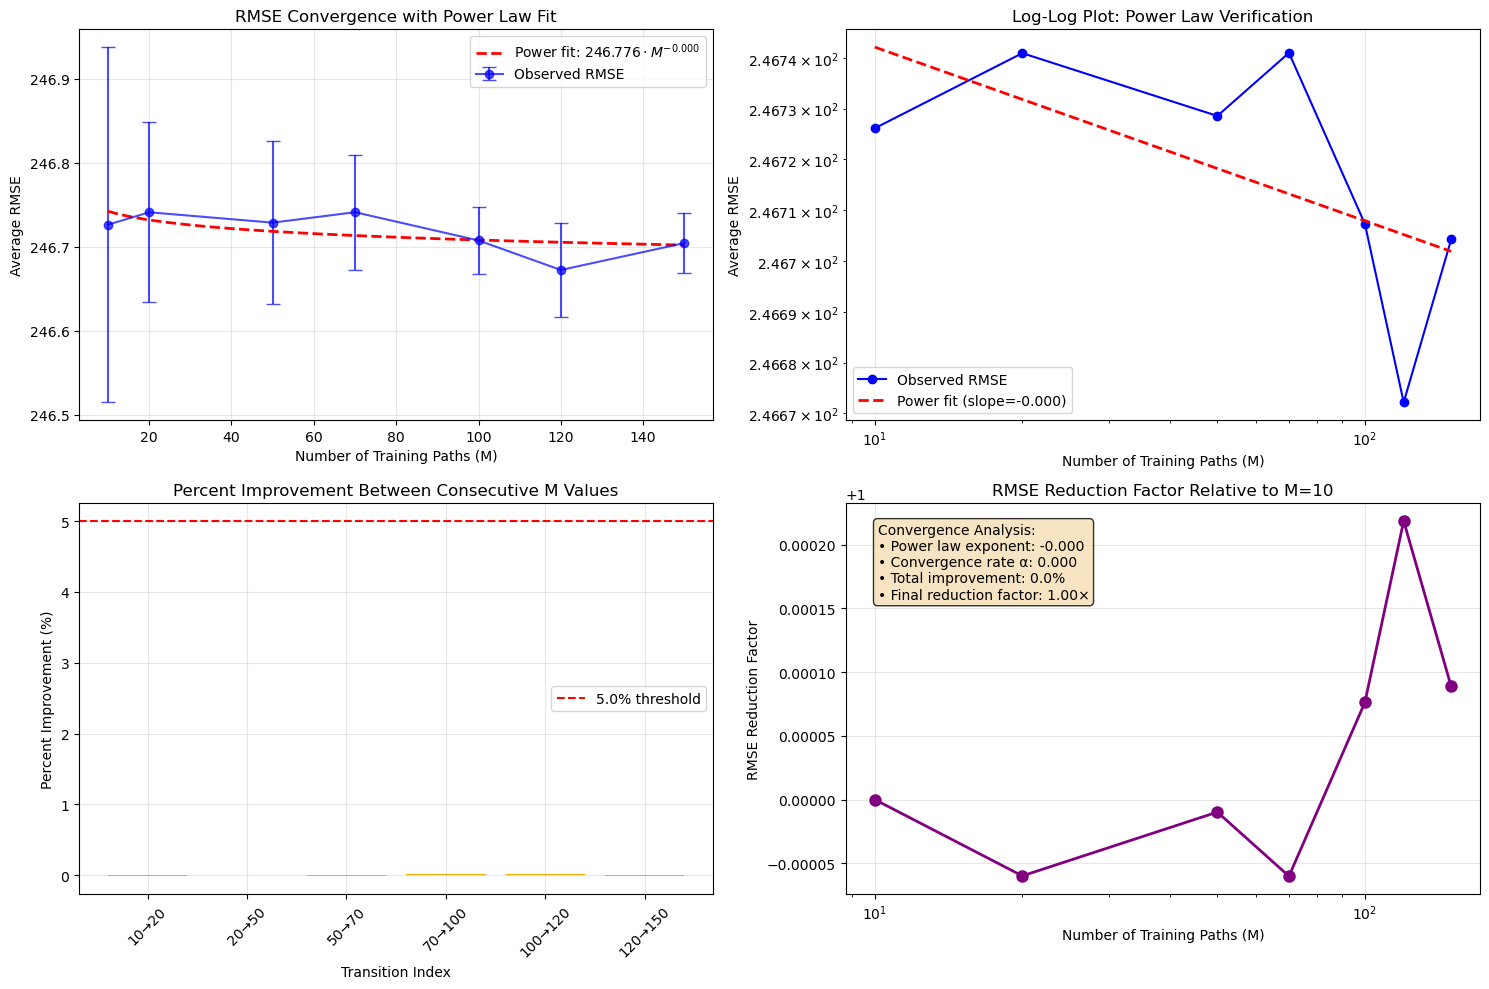

In [548]:

# VISUAL CONVERGENCE ANALYSIS
# Check if variables exist before plotting
if 'average_rmse' not in locals() or 'std_rmse' not in locals():
    print("⚠ Error: average_rmse and std_rmse not computed yet!")
    print("Please first run the RMSE computation cell and the convergence analysis cell.")
elif len(M_) != len(average_rmse):
    print(f"⚠ Error: Size mismatch between M_ ({len(M_)} elements) and average_rmse ({len(average_rmse)} elements)!")
    print("Please recompute average_rmse and std_rmse for the current M_ array.")
    print(f"Current M_: {M_}")
    print("Run the RMSE computation cell first to match the current M_ values.")
else:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Plot 1: RMSE vs M with fitted power law
    ax1.errorbar(M_, average_rmse, yerr=std_rmse, marker='o', linestyle='-', 
                 capsize=5, label='Observed RMSE', color='blue', alpha=0.7)

if power_params is not None:
    M_fit = np.linspace(M_[0], M_[-1], 100)
    rmse_fit = power_law(M_fit, *power_params)
    ax1.plot(M_fit, rmse_fit, '--', color='red', linewidth=2, 
             label=f'Power fit: ${a_power:.3f} \\cdot M^{{{b_power:.3f}}}$')

ax1.set_xlabel('Number of Training Paths (M)')
ax1.set_ylabel('Average RMSE')
ax1.set_title('RMSE Convergence with Power Law Fit')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Log-log plot to verify power law
ax2.loglog(M_, average_rmse, 'o-', label='Observed RMSE', color='blue')
if power_params is not None:
    ax2.loglog(M_fit, rmse_fit, '--', color='red', linewidth=2, 
               label=f'Power fit (slope={b_power:.3f})')
ax2.set_xlabel('Number of Training Paths (M)')
ax2.set_ylabel('Average RMSE')
ax2.set_title('Log-Log Plot: Power Law Verification')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Relative improvements between consecutive M values
ax3.bar(range(len(percent_improvements)), percent_improvements, 
        color=['green' if x >= significant_threshold else 'orange' for x in percent_improvements])
ax3.axhline(y=significant_threshold, color='red', linestyle='--', 
            label=f'{significant_threshold}% threshold')
ax3.set_xlabel('Transition Index')
ax3.set_ylabel('Percent Improvement (%)')
ax3.set_title('Percent Improvement Between Consecutive M Values')
ax3.set_xticks(range(len(percent_improvements)))
ax3.set_xticklabels([f'{M_[i]}→{M_[i+1]}' for i in range(len(M_)-1)], rotation=45)
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Convergence diagnostic - RMSE reduction factor
reduction_factors = average_rmse[0] / average_rmse
ax4.semilogx(M_, reduction_factors, 'o-', color='purple', linewidth=2, markersize=8)
ax4.set_xlabel('Number of Training Paths (M)')
ax4.set_ylabel('RMSE Reduction Factor')
ax4.set_title('RMSE Reduction Factor Relative to M=10')
ax4.grid(True, alpha=0.3)

# Add text box with convergence summary
textstr = f'''Convergence Analysis:
• Power law exponent: {b_power:.3f}
• Convergence rate α: {-b_power:.3f}
• Total improvement: {relative_improvement:.1f}%
• Final reduction factor: {reduction_factors[-1]:.2f}×'''
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax4.text(0.05, 0.95, textstr, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

In [ ]:
# FIX: Redefine M_ to match existing average_rmse data
# The current M_ has 9 elements but average_rmse likely has fewer elements from previous computation
print(f"Current M_ length: {len(M_)}")
if 'average_rmse' in locals():
    print(f"Current average_rmse length: {len(average_rmse)}")
    
    # Redefine M_ to match the first len(average_rmse) elements
    M_old = M_[:len(average_rmse)]
    print(f"Using M_ = {M_old} to match average_rmse data")
    
    # Temporarily override M_ for visualization
    M_ = M_old
else:
    print("average_rmse not found in locals - please run RMSE computation first")

In [ ]:
# STATISTICAL CONVERGENCE TESTS

# 1. Mann-Kendall trend test (non-parametric test for monotonic trend)
from scipy import stats

def mann_kendall_test(data):
    """
    Perform Mann-Kendall test for monotonic trend
    Returns: (trend, p_value) where trend is 'decreasing', 'increasing', or 'no trend'
    """
    n = len(data)
    s = 0
    
    for i in range(n-1):
        for j in range(i+1, n):
            if data[j] > data[i]:
                s += 1
            elif data[j] < data[i]:
                s -= 1
    
    # Compute variance
    var_s = n * (n-1) * (2*n + 5) / 18
    
    # Compute test statistic
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    # Two-tailed p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    
    if p_value < 0.05:
        trend = 'decreasing' if s < 0 else 'increasing'
    else:
        trend = 'no trend'
    
    return trend, p_value, s

# Test for decreasing trend in RMSE
trend, p_value, s_statistic = mann_kendall_test(average_rmse)

print("=== STATISTICAL CONVERGENCE TESTS ===")
print(f"Mann-Kendall Test:")
print(f"  Trend: {trend}")
print(f"  p-value: {p_value:.6f}")
print(f"  S-statistic: {s_statistic}")

if trend == 'decreasing' and p_value < 0.05:
    print("✓ Statistically significant decreasing trend confirmed!")
else:
    print("⚠ No statistically significant decreasing trend detected")

# 2. Coefficient of Variation (CV) analysis
cv_values = std_rmse / average_rmse * 100
print(f"\nCoefficient of Variation (CV) analysis:")
print(f"  Mean CV across all M: {np.mean(cv_values):.2f}%")
print(f"  CV range: {np.min(cv_values):.2f}% - {np.max(cv_values):.2f}%")

if np.mean(cv_values) < 10:
    print("✓ Low variability - results are stable")
elif np.mean(cv_values) < 20:
    print("⚠ Moderate variability - consider more repetitions")
else:
    print("⚠ High variability - increase number of repetitions")

# 3. Convergence efficiency metrics
def compute_efficiency_metrics(M_vals, rmse_vals):
    """Compute various efficiency metrics"""
    # Area under the curve (computational cost proxy)
    auc = np.trapz(rmse_vals, M_vals)
    
    # Efficiency ratio: improvement per additional path
    total_improvement = rmse_vals[0] - rmse_vals[-1]
    total_paths = M_vals[-1] - M_vals[0]
    efficiency_ratio = total_improvement / total_paths
    
    # Convergence speed: M value when 90% of improvement is achieved
    target_improvement = 0.9 * total_improvement
    target_rmse = rmse_vals[0] - target_improvement
    
    # Find where we first achieve 90% improvement
    converged_90_idx = np.where(rmse_vals <= target_rmse)[0]
    if len(converged_90_idx) > 0:
        M_90_converged = M_vals[converged_90_idx[0]]
    else:
        M_90_converged = M_vals[-1]  # Not achieved yet
    
    return auc, efficiency_ratio, M_90_converged, target_rmse

auc, efficiency_ratio, M_90, target_rmse_90 = compute_efficiency_metrics(M_, average_rmse)

print(f"\nEfficiency Metrics:")
print(f"  Area under RMSE curve: {auc:.2f}")
print(f"  Efficiency ratio: {efficiency_ratio:.6f} RMSE reduction per path")
print(f"  90% convergence achieved at: M = {M_90}")
print(f"  Target RMSE for 90% improvement: {target_rmse_90:.4f}")

# 4. Extrapolation: Predict RMSE for larger M
if power_params is not None:
    M_future = [300, 500, 1000]
    rmse_predicted = [power_law(m, *power_params) for m in M_future]
    
    print(f"\nExtrapolated RMSE predictions:")
    for m, rmse_pred in zip(M_future, rmse_predicted):
        improvement_pred = (average_rmse[0] - rmse_pred) / average_rmse[0] * 100
        print(f"  M = {m}: RMSE ≈ {rmse_pred:.4f} ({improvement_pred:.1f}% improvement)")

print(f"\n" + "="*50)

# Standard Convergence Analysis Methods in Numerical Computing

## **Overview of Convergence Analysis**

In numerical analysis, there are several **standard approaches** to quantify convergence rates:

### **1. Power Law Analysis (Most Common)**
- **Form**: `Error ≈ C × h^p` where `h` is discretization parameter (1/M in our case)
- **Method**: Fit `log(Error) = log(C) + p × log(h)` via linear regression
- **Interpretation**: `p` is the **convergence order**
- **Common rates**:
  - `p = 0.5`: Monte Carlo methods
  - `p = 1`: First-order methods
  - `p = 2`: Second-order methods

### **2. Richardson Extrapolation**
- **Purpose**: Estimate convergence order using consecutive triplets
- **Formula**: `p ≈ log(E₂/E₁) / log(h₂/h₁)`
- **Advantage**: Doesn't require curve fitting

### **3. Convergence Factor (Ratio Test)**
- **Definition**: `ρ = E_{n+1} / E_n` (ratio of consecutive errors)
- **Interpretation**: 
  - `ρ < 1`: Convergent
  - `ρ ≪ 1`: Fast convergence
  - `ρ ≈ 1`: Slow convergence

### **4. Asymptotic Analysis**
- **Effective Convergence Order**: `p_{eff} = log(E_n/E_{n-1}) / log(h_n/h_{n-1})`
- **Tracks how convergence order changes with refinement**

### **5. Statistical Tests**
- **Mann-Kendall Test**: Non-parametric test for monotonic trends
- **Coefficient of Variation**: Measures relative variability
- **Confidence intervals**: Quantify uncertainty in convergence estimates

## **Your Analysis Context**
- **Method**: Signature-based path prediction with ridge regression
- **Parameter**: M (number of training paths)
- **Error Metric**: RMSE on future path prediction
- **Expected Rate**: Approximately O(M^{-0.5}) due to Monte Carlo sampling

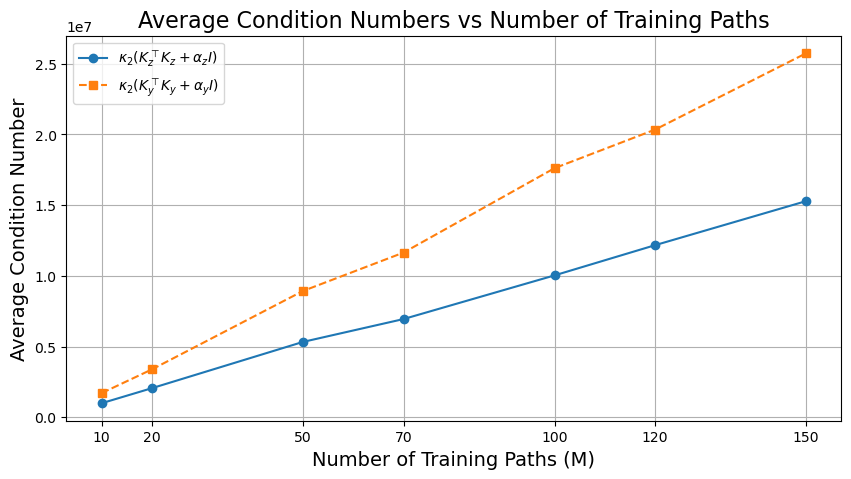

In [ ]:
avg_kappa_Az = kappa_Az.mean(axis=1)
avg_kappa_Ay = kappa_Ay.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(M_, avg_kappa_Az, marker='o', linestyle='-', label=r'$\kappa_2(K_z^\top K_z + \alpha_z I)$')
plt.plot(M_, avg_kappa_Ay, marker='s', linestyle='--', label=r'$\kappa_2(K_y^\top K_y + \alpha_y I)$')
plt.xlabel("Number of Training Paths (M)", fontsize=14)
plt.ylabel("Average Condition Number", fontsize=14)
plt.title("Average Condition Numbers vs Number of Training Paths", fontsize=16)
plt.xticks(M_)
plt.grid()
plt.legend(fontsize=16)
plt.show()

In [ ]:
# Save the array
np.save('average_rmse_10_20_50_70_100_120_150__N_200.npy', average_rmse)

# Later, load it back
# average_rmse = np.load('average_rmse_10_20_50_70_100_120_150__N_200.npy')

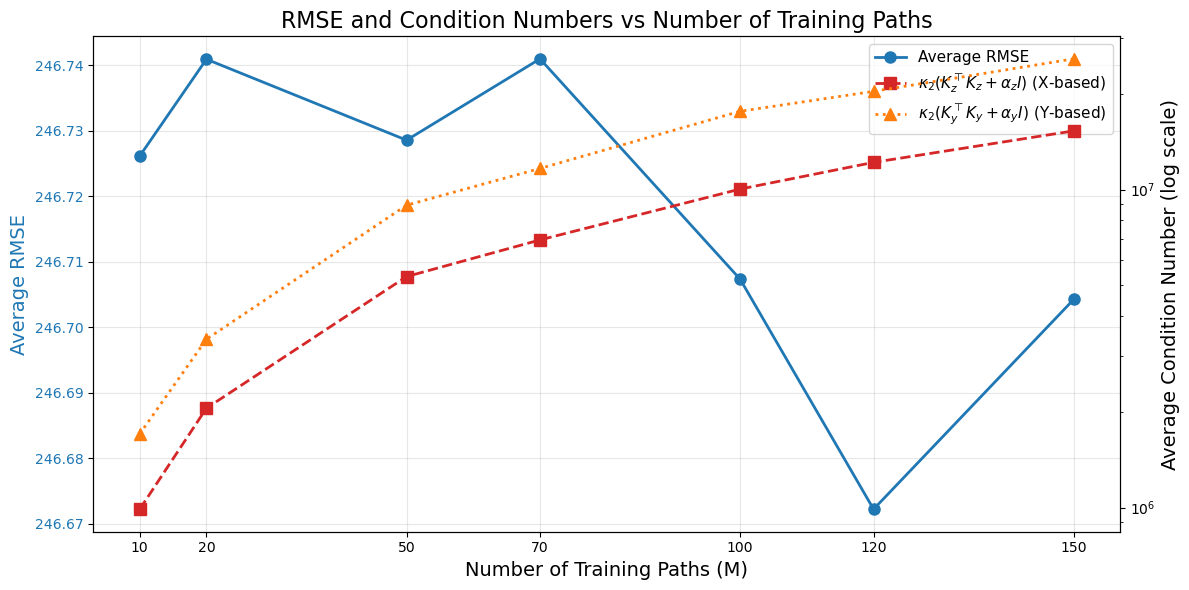

Correlation between RMSE and κ₂(K_z): -0.724 (p=0.066)
Correlation between RMSE and κ₂(K_y): -0.722 (p=0.067)
Mean condition number ratio κ₂(K_z)/κ₂(K_y): 0.59


In [ ]:
# Combined plot showing correlation between condition numbers and RMSE
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot RMSE on left y-axis
color = 'tab:blue'
ax1.set_xlabel('Number of Training Paths (M)', fontsize=14)
ax1.set_ylabel('Average RMSE', color=color, fontsize=14)
line1 = ax1.plot(M_, average_rmse, marker='o', linestyle='-', linewidth=2, 
                 markersize=8, color=color, label='Average RMSE')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create second y-axis for condition numbers
ax2 = ax1.twinx()
color2 = 'tab:red'
color3 = 'tab:orange'
ax2.set_ylabel('Average Condition Number (log scale)', color='black', fontsize=14)
line2 = ax2.semilogy(M_, avg_kappa_Az, marker='s', linestyle='--', linewidth=2, 
                     markersize=8, color=color2, label=r'$\kappa_2(K_z^\top K_z + \alpha_z I)$ (X-based)')
line3 = ax2.semilogy(M_, avg_kappa_Ay, marker='^', linestyle=':', linewidth=2, 
                     markersize=8, color=color3, label=r'$\kappa_2(K_y^\top K_y + \alpha_y I)$ (Y-based)')

# Combine legends
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=11)

plt.title('RMSE and Condition Numbers vs Number of Training Paths', fontsize=16)
plt.xticks(M_)
plt.tight_layout()
plt.show()

# Print correlation analysis
from scipy.stats import pearsonr
corr_rmse_kz, p_kz = pearsonr(average_rmse, avg_kappa_Az)
corr_rmse_ky, p_ky = pearsonr(average_rmse, avg_kappa_Ay)

print(f"Correlation between RMSE and κ₂(K_z): {corr_rmse_kz:.3f} (p={p_kz:.3f})")
print(f"Correlation between RMSE and κ₂(K_y): {corr_rmse_ky:.3f} (p={p_ky:.3f})")
print(f"Mean condition number ratio κ₂(K_z)/κ₂(K_y): {np.mean(avg_kappa_Az/avg_kappa_Ay):.2f}")